## ZENITHBANK STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

zenithbank=pd.read_csv('../stock_data/zenithbank.csv') ## so it can be small letter. This is cool.
zenithbank=zenithbank.drop(columns=['high_price','low_price'])
zenithbank.rename(columns={'trade_date':'date'},inplace=True)
zenithbank['date']=pd.to_datetime(zenithbank['date'])
zenithbank['month']=zenithbank['date'].dt.month
zenithbank['quarter']=zenithbank['date'].dt.quarter
zenithbank['year']=zenithbank['date'].dt.year

zenithbank

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42777,ZENITHBANK,2017-01-03,14.40,14.40,2751524,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43337,ZENITHBANK,2017-01-04,14.55,14.55,3551777,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43447,ZENITHBANK,2017-01-05,14.50,14.50,8601136,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43557,ZENITHBANK,2017-01-06,14.77,14.77,20814786,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43647,ZENITHBANK,2017-01-09,15.49,15.49,8851535,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298160,ZENITHBANK,2026-07-13,107.20,107.20,16801126,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298598,ZENITHBANK,2026-07-14,108.60,108.60,15923120,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,299036,ZENITHBANK,2026-07-15,109.00,109.00,30042445,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299474,ZENITHBANK,2026-07-16,111.00,111.00,15936093,2026-07-16T15:10:03.113936+00:00,7,3,2026


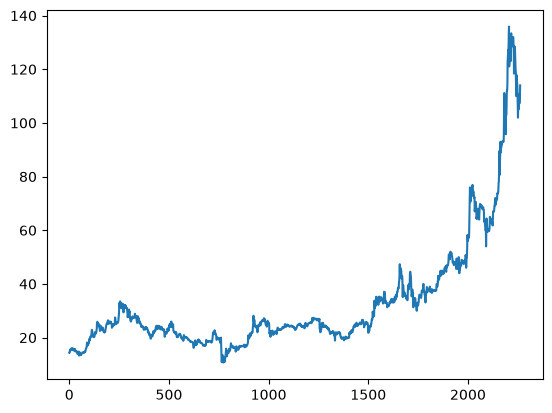

In [2]:
import matplotlib.pyplot as plt

plt.plot(zenithbank['close_price'])
plt.show()

In [3]:
zenithbank_end_month_df = (
    zenithbank
    .sort_values("date")
    .groupby(zenithbank["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

zenithbank_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45347,ZENITHBANK,2017-01-31,15.70,15.70,11515023,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47168,ZENITHBANK,2017-02-28,14.70,14.70,107253911,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49284,ZENITHBANK,2017-03-31,14.05,14.05,69127067,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51112,ZENITHBANK,2017-04-28,14.90,14.90,30843771,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53034,ZENITHBANK,2017-05-31,18.95,18.95,26567711,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35399,ZENITHBANK,2026-03-31,95.80,95.80,24066107,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281224,ZENITHBANK,2026-04-30,130.50,130.50,38422905,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284290,ZENITHBANK,2026-05-29,131.00,131.00,15514914,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294218,ZENITHBANK,2026-06-30,110.00,110.00,21043685,2026-06-30T15:10:03.08168+00:00,6,2,2026


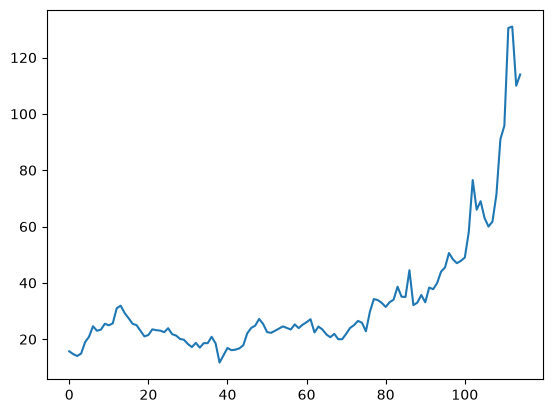

In [4]:
plt.plot(zenithbank_end_month_df['close_price'])
plt.show()

In [5]:
zenithbank_end_month_df['returns']=zenithbank_end_month_df['close_price'].pct_change()*100
zenithbank_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45347,ZENITHBANK,2017-01-31,15.70,15.70,11515023,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47168,ZENITHBANK,2017-02-28,14.70,14.70,107253911,2026-04-08T02:44:45.006295+00:00,2,1,2017,-6.369427
2,49284,ZENITHBANK,2017-03-31,14.05,14.05,69127067,2026-04-08T02:45:42.281198+00:00,3,1,2017,-4.421769
3,51112,ZENITHBANK,2017-04-28,14.90,14.90,30843771,2026-04-08T02:51:55.619599+00:00,4,2,2017,6.049822
4,53034,ZENITHBANK,2017-05-31,18.95,18.95,26567711,2026-04-08T02:52:57.421655+00:00,5,2,2017,27.181208
...,...,...,...,...,...,...,...,...,...,...,...
110,35399,ZENITHBANK,2026-03-31,95.80,95.80,24066107,2026-03-31T15:00:02.085058+00:00,3,1,2026,5.274725
111,281224,ZENITHBANK,2026-04-30,130.50,130.50,38422905,2026-04-30T15:00:02.170664+00:00,4,2,2026,36.221294
112,284290,ZENITHBANK,2026-05-29,131.00,131.00,15514914,2026-05-29T15:00:02.455558+00:00,5,2,2026,0.383142
113,294218,ZENITHBANK,2026-06-30,110.00,110.00,21043685,2026-06-30T15:10:03.08168+00:00,6,2,2026,-16.030534


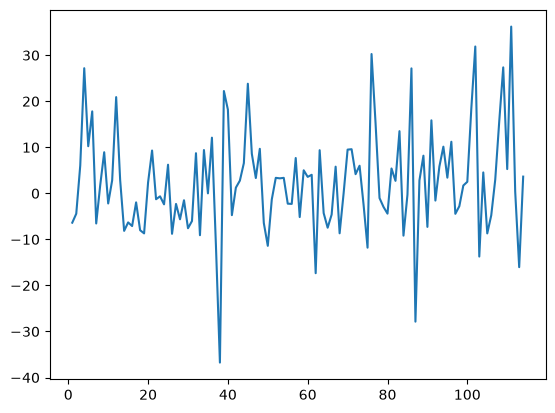

In [6]:
plt.plot(zenithbank_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(zenithbank_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-10.58161311407601), np.float64(6.882360163549669e-19), 0, 113, {'1%': np.float64(-3.489589552580676), '5%': np.float64(-2.887477210140433), '10%': np.float64(-2.580604145195395)}, np.float64(774.3792120451399))
stationary


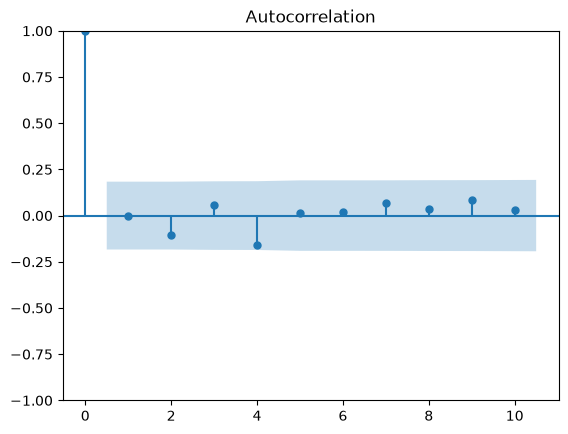

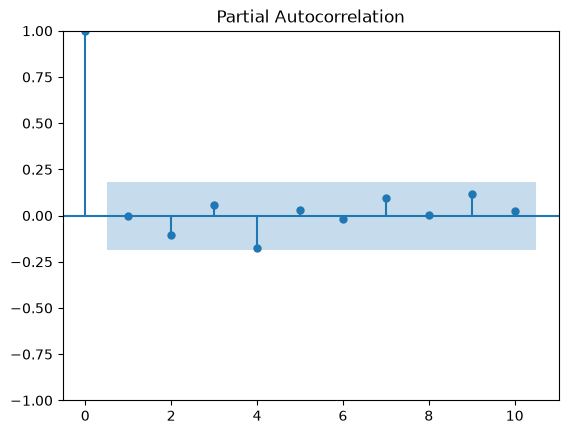

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(zenithbank_end_month_df['returns'].dropna(), lags=10)
plot_pacf(zenithbank_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=zenithbank_end_month_df['close_price'][:-10]
test=zenithbank_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -12.284359913230645]
[0, 0, 0, 0, 0, 1, -5.502987357845176]
[0, 0, 0, 0, 0, 2, -4.214737369564808]
[0, 0, 0, 0, 1, 0, -2.328485822330411]
[0, 0, 0, 0, 1, 1, -2.199376229719177]
[0, 0, 0, 0, 1, 2, -2.149173618549089]
[0, 0, 0, 0, 2, 0, -0.8782150839493024]
[0, 0, 0, 0, 2, 1, -1.298524864273865]
[0, 0, 0, 0, 2, 2, -1.3303732843077545]
[0, 0, 0, 1, 0, 0, -2.5405949546575077]
[0, 0, 0, 1, 0, 1, -2.4502850881358227]
[0, 0, 0, 1, 0, 2, -2.3923817716451534]
[0, 0, 0, 1, 1, 0, -2.1359816770681674]
[0, 0, 0, 1, 1, 1, -1.9073790000400925]
[0, 0, 0, 1, 1, 2, -1.9779402676177043]
[0, 0, 0, 1, 2, 0, -1.153160325545794]
[0, 0, 0, 1, 2, 1, -1.3521991327926122]
[0, 0, 0, 1, 2, 2, -1.3052164333449405]
[0, 0, 0, 2, 0, 0, -2.420309295392835]
[0, 0, 0, 2, 0, 1, -2.5860834710899074]
[0, 0, 0, 2, 0, 2, -2.420059743316448]
[0, 0, 0, 2, 1, 0, -1.9159818178008483]
[0, 0, 0, 2, 1, 1, -1.929840801103743]
[0, 0, 0, 2, 1, 2, -1.9189936385917687]
[0, 0, 0, 2, 2, 0, -1.4072922090265667]
[0, 0, 0, 

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
0,0,0,0,0,0,0,-12.284360
27,0,0,1,0,0,0,-11.757549
54,0,0,2,0,0,0,-11.325506
55,0,0,2,0,0,1,-5.918969
1,0,0,0,0,0,1,-5.502987
...,...,...,...,...,...,...,...
176,0,2,0,1,1,2,0.498739
185,0,2,0,2,1,2,0.498861
184,0,2,0,2,1,1,0.500309
174,0,2,0,1,1,0,0.505649


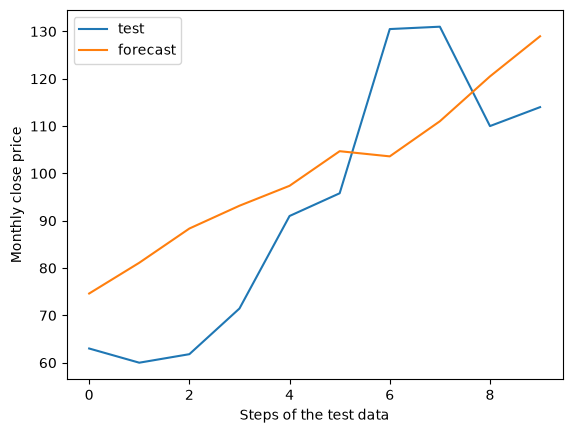

r2_score:  0.5248723923053574
rmse:  18.261403866394442
description:  count    115.000000
mean      33.364435
std       22.913401
min       11.700000
25%       21.600000
50%       24.800000
75%       34.625000
max      131.000000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=zenithbank_end_month_df['close_price'][:-10]
y_test=zenithbank_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(0,2,0), 
seasonal_order=(2,1,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', zenithbank_end_month_df.close_price.describe())

Its not capturing the variations properly. Lets try the returns

In [12]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=zenithbank_end_month_df['returns'].dropna()[:-10]
test=zenithbank_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.16532082825284977]
[0, 0, 0, 0, 0, 1, -0.17262121380429285]
[0, 0, 0, 0, 0, 2, -0.2965344335185631]
[0, 0, 0, 0, 1, 0, -1.0242282431131158]
[0, 0, 0, 0, 1, 1, -0.38885714808426863]
[0, 0, 0, 0, 1, 2, -0.3932241884926644]
[0, 0, 0, 0, 2, 0, -3.46051631212919]
[0, 0, 0, 0, 2, 1, -1.1302304804252516]
[0, 0, 0, 0, 2, 2, -1.3904566477478992]
[0, 0, 0, 1, 0, 0, -0.17766171861474]
[0, 0, 0, 1, 0, 1, -0.2270483420543048]
[0, 0, 0, 1, 0, 2, -0.2270820178695736]
[0, 0, 0, 1, 1, 0, -1.1075912304082696]
[0, 0, 0, 1, 1, 1, -0.39464406346926606]
[0, 0, 0, 1, 1, 2, -0.40791454752287515]
[0, 0, 0, 1, 2, 0, -1.5562327234909965]
[0, 0, 0, 1, 2, 1, -1.219160223740615]
[0, 0, 0, 1, 2, 2, -1.3837000740262262]
[0, 0, 0, 2, 0, 0, -0.2734345057507057]
[0, 0, 0, 2, 0, 1, -0.29639374097258675]
[0, 0, 0, 2, 0, 2, -0.23474354675488818]
[0, 0, 0, 2, 1, 0, -1.0260938633850492]
[0, 0, 0, 2, 1, 1, -0.40990157756668855]
[0, 0, 0, 2, 1, 2, -0.4053040758754054]
[0, 0, 0, 2, 2, 0, -2.512476856447666

In [13]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
168,0,2,0,0,2,0,-486.602980
169,0,2,0,0,2,1,-283.075585
188,0,2,0,2,2,2,-278.335797
186,0,2,0,2,2,0,-265.472339
187,0,2,0,2,2,1,-265.116621
...,...,...,...,...,...,...,...
81,0,1,0,0,0,0,-0.011778
189,0,2,1,0,0,0,-0.002666
459,1,2,2,0,0,0,0.002777
216,0,2,2,0,0,0,0.002956


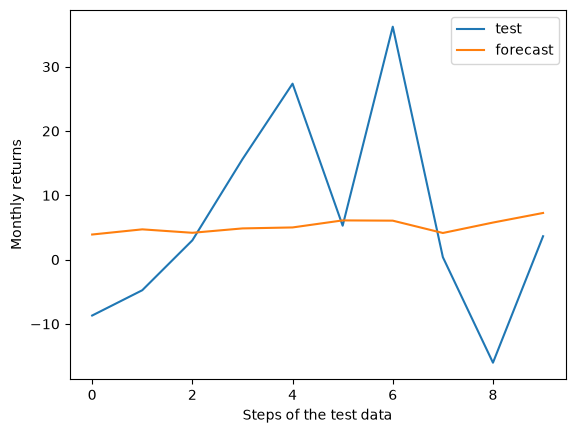

r2_score:  0.020332196731749685
rmse:  15.093714225284819
description:  count    114.000000
mean       2.385634
std       11.386423
min      -36.756757
25%       -4.702370
50%        2.445706
75%        8.493418
max       36.221294
Name: returns, dtype: float64


In [14]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=zenithbank_end_month_df['returns'].dropna()[:-10]
y_test=zenithbank_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(0,2,1), 
seasonal_order=(1,0,2,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly returns')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', zenithbank_end_month_df.returns.dropna().describe())

Very horrible. We will work with close_price
